In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:/DLM Research/processed_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54530 entries, 0 to 54529
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          54530 non-null  float64
 1   delivery_datetime                   54498 non-null  object 
 2   fundal_height_cm                    54530 non-null  int64  
 3   maternal_age_years                  54530 non-null  float64
 4   maternal_weight_kg                  54530 non-null  float64
 5   gestational_age_weeks               54530 non-null  object 
 6   fetal_presentation                  54530 non-null  object 
 7   fetal_lie                           54530 non-null  object 
 8   placenta_status                     54530 non-null  object 
 9   maternal_outcome_status             54530 non-null  object 
 10  history_hypertension                54530 non-null  float64
 11  history_diabetes                    54530

In [4]:
df = df.copy()

# Target
y = df['Cesarean Section']

# Drop non-informative columns
X = df.drop(columns=['Cesarean Section', 'patient_id', 'delivery_datetime'])

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
print(X_train.shape) 
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(43624, 29)
(10906, 29)
(43624,)
(10906,)


In [7]:
# 1. Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2. Identify categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# 3. Apply one-hot encoding on TRAIN
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)

# 4. Apply same transformation to TEST (align columns)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# 5. Align test set to training columns (very important!)
X_train, X_test = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

In [8]:
X_train

,fundal_height_cm,maternal_age_years,maternal_weight_kg,history_hypertension,history_diabetes,history_cardiac_disease,history_surgery,history_obstetric_complications,history_infection,history_anemia,...,fetal_presentation_Transverse/Shoulder,fetal_lie_Oblique,fetal_lie_Transverse,placenta_status_Incomplete,maternal_outcome_status_Stable,maternal_outcome_status_Unstable,maternal_outcome_status_Unstable & Referred,health_facility_Minilik Hospital,health_facility_Yekatit Hospital,health_facility_Zewuditu Hospital
26604,34,28.0,65.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
6309,38,35.0,67.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
43664,36,29.0,63.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,True
43080,28,23.0,67.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,True,False,False
11124,34,20.0,69.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19357,36,35.0,72.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
36819,30,35.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
29512,36,32.0,69.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
44113,34,28.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,True


In [9]:
X_test

,fundal_height_cm,maternal_age_years,maternal_weight_kg,history_hypertension,history_diabetes,history_cardiac_disease,history_surgery,history_obstetric_complications,history_infection,history_anemia,...,fetal_presentation_Transverse/Shoulder,fetal_lie_Oblique,fetal_lie_Transverse,placenta_status_Incomplete,maternal_outcome_status_Stable,maternal_outcome_status_Unstable,maternal_outcome_status_Unstable & Referred,health_facility_Minilik Hospital,health_facility_Yekatit Hospital,health_facility_Zewuditu Hospital
19987,34,27.0,77.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
44586,36,26.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,True
16184,30,32.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
43950,30,28.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,True
43349,36,26.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9210,34,24.0,58.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
45127,32,37.0,81.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,True
4084,36,30.0,61.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
49283,36,21.0,72.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,True


In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43624 entries, 26604 to 53892
Data columns (total 36 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   fundal_height_cm                             43624 non-null  int64  
 1   maternal_age_years                           43624 non-null  float64
 2   maternal_weight_kg                           43624 non-null  float64
 3   history_hypertension                         43624 non-null  float64
 4   history_diabetes                             43624 non-null  float64
 5   history_cardiac_disease                      43624 non-null  float64
 6   history_surgery                              43624 non-null  float64
 7   history_obstetric_complications              43624 non-null  float64
 8   history_infection                            43624 non-null  float64
 9   history_anemia                               43624 non-null  float64
 10 

In [11]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10906 entries, 19987 to 27273
Data columns (total 36 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   fundal_height_cm                             10906 non-null  int64  
 1   maternal_age_years                           10906 non-null  float64
 2   maternal_weight_kg                           10906 non-null  float64
 3   history_hypertension                         10906 non-null  float64
 4   history_diabetes                             10906 non-null  float64
 5   history_cardiac_disease                      10906 non-null  float64
 6   history_surgery                              10906 non-null  float64
 7   history_obstetric_complications              10906 non-null  float64
 8   history_infection                            10906 non-null  float64
 9   history_anemia                               10906 non-null  float64
 10 

In [12]:
y_train

26604    1.0
6309     0.0
43664    0.0
43080    1.0
11124    0.0
        ... 
19357    0.0
36819    1.0
29512    0.0
44113    0.0
53892    1.0
Name: Cesarean Section, Length: 43624, dtype: float64

In [13]:
y_test

19987    0.0
44586    0.0
16184    0.0
43950    1.0
43349    0.0
        ... 
9210     0.0
45127    1.0
4084     0.0
49283    1.0
27273    1.0
Name: Cesarean Section, Length: 10906, dtype: float64

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Train model on training data
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Select important features
selector = SelectFromModel(rf, threshold='median')  # keep top ~50%
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]

print("Selected Features:", selected_features)

Selected Features: Index(['fundal_height_cm', 'maternal_age_years', 'maternal_weight_kg',
       'history_surgery', 'maternal_pulse_rate_bpm',
       'maternal_respiratory_rate_bpm', 'maternal_oxygen_saturation_percent',
       'fetal_heart_rate_bpm', 'systolic_blood_pressure_mmhg',
       'diastolic_blood_pressure_mmhg', 'preeclampsia', 'gravidity', 'parity',
       'gestational_age_weeks_Term', 'fetal_presentation_Cephalic',
       'health_facility_Minilik Hospital', 'health_facility_Yekatit Hospital',
       'health_facility_Zewuditu Hospital'],
      dtype='object')


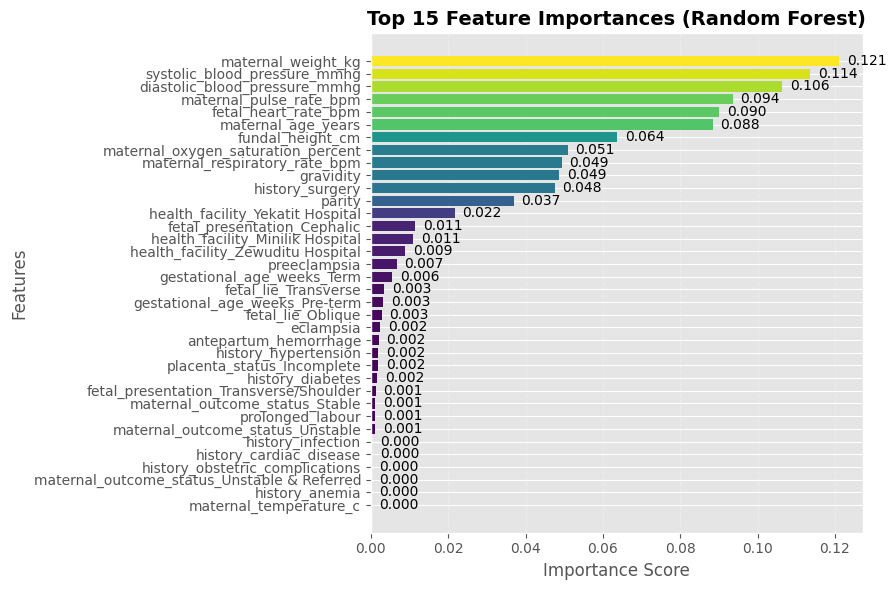

In [15]:
# Feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train_encoded.columns)

# Top 15
top_features = feat_imp.sort_values(ascending=False).head(36)

plt.figure(figsize=(9,6))

# Color gradient based on importance
colors = plt.cm.viridis(top_features.values / max(top_features.values))

bars = plt.barh(top_features.index, top_features.values, color=colors)

plt.gca().invert_yaxis()

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va='center',
        fontsize=10
    )

plt.title("Top 15 Feature Importances (Random Forest)", fontsize=14, weight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

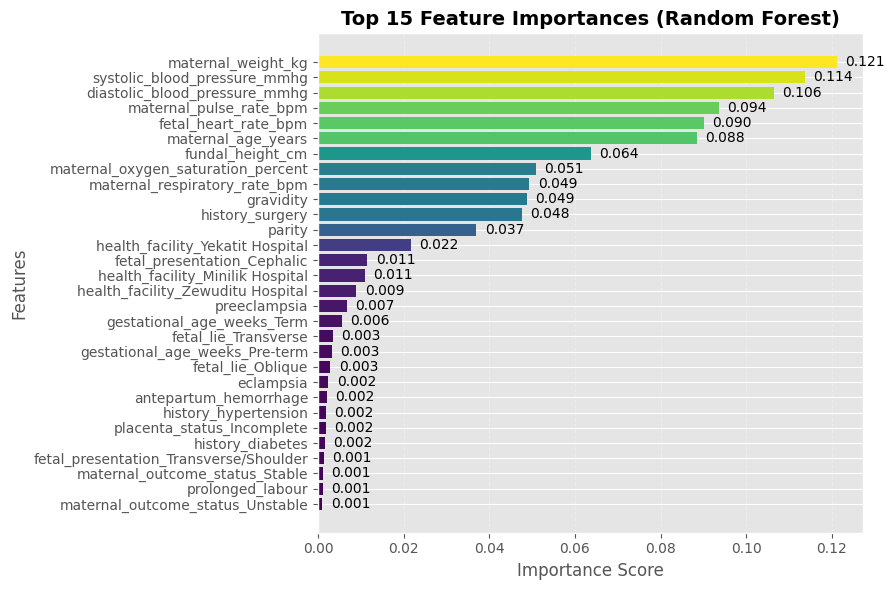

In [16]:
# Feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train_encoded.columns)

# Top 15
top_features = feat_imp.sort_values(ascending=False).head(30)

plt.figure(figsize=(9,6))

# Color gradient based on importance
colors = plt.cm.viridis(top_features.values / max(top_features.values))

bars = plt.barh(top_features.index, top_features.values, color=colors)

plt.gca().invert_yaxis()

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va='center',
        fontsize=10
    )

plt.title("Top 15 Feature Importances (Random Forest)", fontsize=14, weight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Scaling

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
}

# Train models
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("-"*40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Logistic Regression
----------------------------------------
Accuracy: 0.6490005501558775
Confusion Matrix:
 [[5630  875]
 [2953 1448]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.66      0.87      0.75      6505
         1.0       0.62      0.33      0.43      4401

    accuracy                           0.65     10906
   macro avg       0.64      0.60      0.59     10906
weighted avg       0.64      0.65      0.62     10906


Random Forest
----------------------------------------
Accuracy: 0.6401980561158995
Confusion Matrix:
 [[5526  979]
 [2945 1456]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.65      0.85      0.74      6505
         1.0       0.60      0.33      0.43      4401

    accuracy                           0.64     10906
   macro avg       0.63      0.59      0.58     10906
weighted avg       0.63      0.64      0.61     10906


Gradient Boosting
-----------

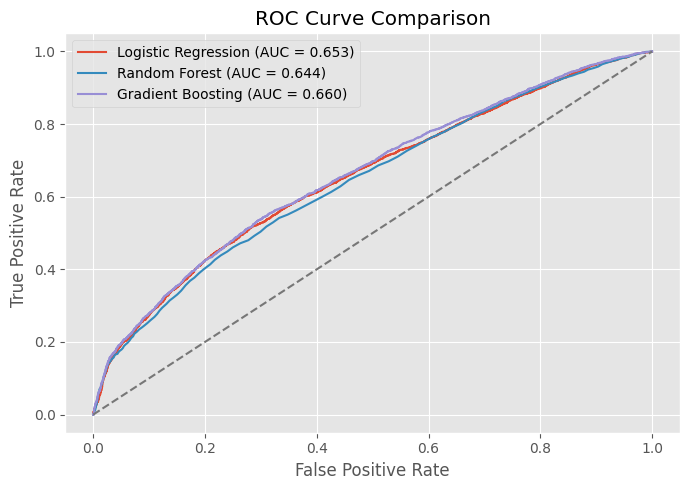

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# Diagonal line (random model)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

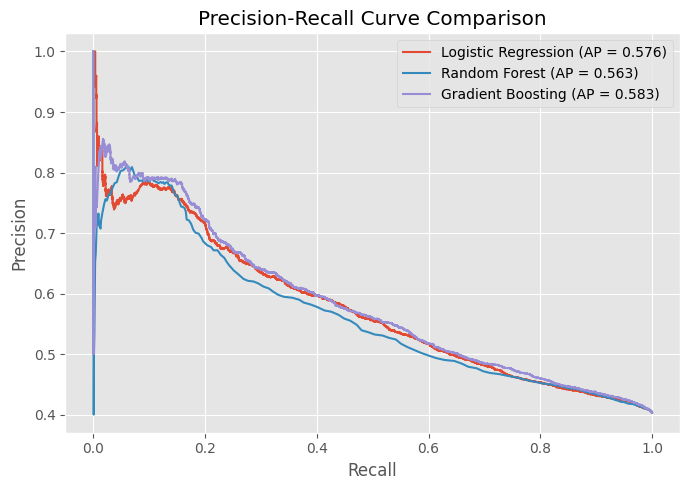

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,5))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
import os

# Create directory if it doesn't exist
os.makedirs("D:/DLM Research", exist_ok=True)

# Save feature sets
X_train.to_csv("D:/DLM Research/X_train.csv", index=False)
X_test.to_csv("D:/DLM Research/X_test.csv", index=False)

# Save target variables
y_train.to_csv("D:/DLM Research/y_train.csv", index=False)
y_test.to_csv("D:/DLM Research/y_test.csv", index=False)